In [358]:
# Install the library
# %pip install pythae

In [359]:
import torch
import torchvision.datasets as datasets

device = "cuda" if torch.cuda.is_available() else "cpu"

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [360]:
mnist_trainset = datasets.MNIST(root='../../data', train=True, download=True, transform=None)

train_dataset = mnist_trainset.data[:-10000].reshape(-1, 1, 28, 28) / 255.0
eval_dataset = mnist_trainset.data[-10000:].reshape(-1, 1, 28, 28) / 255.0

# train_dataset = train_dataset.float()
# eval_dataset = eval_dataset.float()


In [361]:
from pythae.models import AmortizedDualVAE, AmortizedDualVAEConfig
from pythae.trainers import BaseTrainerConfig
from pythae.pipelines.training import TrainingPipeline


In [362]:
config = BaseTrainerConfig(
    output_dir='my_amortized_dual_vae',
    learning_rate=1e-4,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    num_epochs=10,  # Increase for more training
    optimizer_cls="AdamW",
    optimizer_params={"weight_decay": 0.05, "betas": (0.91, 0.99)}
)

model_config = AmortizedDualVAEConfig(
    input_dim=(1, 28, 28),
    latent_dim=16,
    polynomial_order=2,
    langevin_steps=10,
    langevin_step_size=1e-2,
    langevin_n_samples=8
)

model = AmortizedDualVAE(
    model_config=model_config
)


In [363]:
# from pythae.trainers.training_callbacks import WandbCallback
# callbacks = []
# wandb_cb = WandbCallback()
# wandb_cb.setup(training_config=config, # training config
#     model_config=model_config, # model config
#     project_name="memvae", # specify your wandb project
# )
# callbacks.append(wandb_cb)

In [364]:
pipeline = TrainingPipeline(
    training_config=config,
    model=model
)


In [365]:
pipeline(
    train_data=train_dataset,
    eval_data=eval_dataset,
    # callbacks=callbacks
)


Preprocessing train data...
Checking train dataset...
Preprocessing eval data...

Checking eval dataset...
Using Base Trainer

Model passed sanity check !
Ready for training.

Created my_amortized_dual_vae/AmortizedDualVAE_training_2025-10-19_14-54-15. 
Training config, checkpoints and final model will be saved here.

Training params:
 - max_epochs: 10
 - per_device_train_batch_size: 64
 - per_device_eval_batch_size: 64
 - checkpoint saving every: None
Optimizer: AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.91, 0.99)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0.05
)
Scheduler: None

Successfully launched training !



reconstruction loss: 92.60630798339844 score proxy: 0.00011876938515342772 dual proxy: 0.00080069899559021 moment loss: 1.5190802812576294 lambda reg: 0.001171395182609558 reencode loss: 0.05149584636092186


Training of epoch 1/10:   0%|          | 0/782 [00:00<?, ?batch/s]

reconstruction loss: 92.88233947753906 score proxy: 7.94949010014534e-05 dual proxy: 0.015149138867855072 moment loss: 2.0553483963012695 lambda reg: 0.0011456265347078443 reencode loss: 0.052828989923000336
reconstruction loss: 92.01996612548828 score proxy: -0.00014552359061781317 dual proxy: -0.0749569907784462 moment loss: 2.040900707244873 lambda reg: 0.0011269297683611512 reencode loss: 0.03880177065730095
reconstruction loss: 90.7282943725586 score proxy: -0.00013553407916333526 dual proxy: -0.39004701375961304 moment loss: 1.7611125707626343 lambda reg: 0.0011418273206800222 reencode loss: 0.029411742463707924
reconstruction loss: 89.6039810180664 score proxy: -0.00021349340386223048 dual proxy: -0.4225139319896698 moment loss: 1.7803794145584106 lambda reg: 0.0011717025190591812 reencode loss: 0.02350965328514576
reconstruction loss: 88.87509155273438 score proxy: -7.347868631768506e-06 dual proxy: -0.4126085937023163 moment loss: 1.6787583827972412 lambda reg: 0.0012166703818

Eval of epoch 1/10:   0%|          | 0/157 [00:00<?, ?batch/s]

...

reconstruction loss: 9.255504608154297 score proxy: -1.4648076295852661 dual proxy: -51.955596923828125 moment loss: 2.8756699562072754 lambda reg: 9.92380142211914 reencode loss: 0.3176814615726471
reconstruction loss: 8.195586204528809 score proxy: -0.9539156556129456 dual proxy: -33.35711669921875 moment loss: 3.366595506668091 lambda reg: 9.970844268798828 reencode loss: 0.3669487237930298
reconstruction loss: 8.390714645385742 score proxy: -0.7515910267829895 dual proxy: -44.765357971191406 moment loss: 3.3330934047698975 lambda reg: 10.230563163757324 reencode loss: 0.3447604477405548
reconstruction loss: 8.102848052978516 score proxy: -0.5968760848045349 dual proxy: -33.787994384765625 moment loss: 3.3521194458007812 lambda reg: 9.479853630065918 reencode loss: 0.33457285165786743
reconstruction loss: 8.362726211547852 score proxy: -0.8170332312583923 dual proxy: -47.730247497558594 moment loss: 3.3979432582855225 lambda reg: 10.160667419433594 reencode loss: 0.3352543115615845


Eval of epoch 10/10:   0%|          | 0/157 [00:00<?, ?batch/s]

reconstruction loss: 8.025422096252441 score proxy: -1.6441110372543335 dual proxy: -68.2767333984375 moment loss: 2.669632911682129 lambda reg: 10.390524864196777 reencode loss: 0.3200833797454834
reconstruction loss: 8.243392944335938 score proxy: -0.8831807374954224 dual proxy: -62.34623718261719 moment loss: 2.9526901245117188 lambda reg: 10.478367805480957 reencode loss: 0.32912948727607727
reconstruction loss: 8.472689628601074 score proxy: -1.0413014888763428 dual proxy: -64.35577392578125 moment loss: 3.041309356689453 lambda reg: 10.553876876831055 reencode loss: 0.3003009557723999
reconstruction loss: 8.680971145629883 score proxy: -0.8214079737663269 dual proxy: -56.64583969116211 moment loss: 3.047030448913574 lambda reg: 10.4725341796875 reencode loss: 0.3295673727989197
reconstruction loss: 8.07394790649414 score proxy: -0.6198942065238953 dual proxy: -54.68477249145508 moment loss: 3.4528286457061768 lambda reg: 10.5018310546875 reencode loss: 0.3444201946258545
reconstr

--------------------------------------------------------------------------
Train loss: 12.3234
Eval loss: 11.9658
--------------------------------------------------------------------------
Training ended!
Saved final model in my_amortized_dual_vae/AmortizedDualVAE_training_2025-10-19_14-54-15/final_model


reconstruction loss: 8.524287223815918 score proxy: -0.7275586724281311 dual proxy: -46.52008056640625 moment loss: 3.3840227127075195 lambda reg: 10.138465881347656 reencode loss: 0.3385472595691681
reconstruction loss: 8.4495210647583 score proxy: -1.0488348007202148 dual proxy: -58.21967315673828 moment loss: 3.1034398078918457 lambda reg: 10.355489730834961 reencode loss: 0.3139938414096832
reconstruction loss: 9.58506965637207 score proxy: -1.302998423576355 dual proxy: -65.40824127197266 moment loss: 2.8303778171539307 lambda reg: 9.686363220214844 reencode loss: 0.3595309853553772


In [366]:
import os
from pythae.models import AutoModel


In [367]:
last_training = sorted(os.listdir(config.output_dir))[-1]
trained_model = AutoModel.load_from_folder(os.path.join(config.output_dir, last_training, 'final_model'))
trained_model = trained_model.to(device)
trained_model.eval()


AmortizedDualVAE(
  (decoder): Decoder_AE_MLP(
    (layers): ModuleList(
      (0): Sequential(
        (0): Linear(in_features=16, out_features=512, bias=True)
        (1): ReLU()
      )
      (1): Sequential(
        (0): Linear(in_features=512, out_features=784, bias=True)
        (1): Sigmoid()
      )
    )
  )
  (encoder): MomentsEncoderMLP(
    (layers): ModuleList(
      (0): Sequential(
        (0): Linear(in_features=784, out_features=512, bias=True)
        (1): ReLU()
      )
      (1): Sequential(
        (0): Linear(in_features=512, out_features=512, bias=True)
        (1): ReLU()
      )
    )
    (head): Linear(in_features=512, out_features=152, bias=True)
  )
  (lambda_net): LambdaNetMLP(
    (net): Sequential(
      (0): Linear(in_features=152, out_features=512, bias=True)
      (1): ReLU()
      (2): Linear(in_features=512, out_features=512, bias=True)
      (3): ReLU()
      (4): Linear(in_features=512, out_features=152, bias=True)
    )
  )
)

## Sampling with the energy-based latent prior


In [368]:
import matplotlib.pyplot as plt

def sample_amortized_dual_vae(model, num_samples=25, reference_batch=None):
    device = next(model.parameters()).device
    model.eval()
    with torch.no_grad():
        if reference_batch is None:
            idx = torch.randint(0, train_dataset.shape[0], (num_samples,))
            reference_batch = train_dataset[idx]
        else:
            reference_batch = reference_batch[:num_samples]
        reference_batch = reference_batch.to(device)
        moments = model.encoder(reference_batch)["embedding"]
        lam = model.lambda_net(moments)
        latent_samples = model.sampler.sample(lam, model.basis)[:, -1, :]
        decoded = model.decoder(latent_samples)["reconstruction"]
    return decoded.cpu()


In [369]:
generated = sample_amortized_dual_vae(trained_model, num_samples=25)


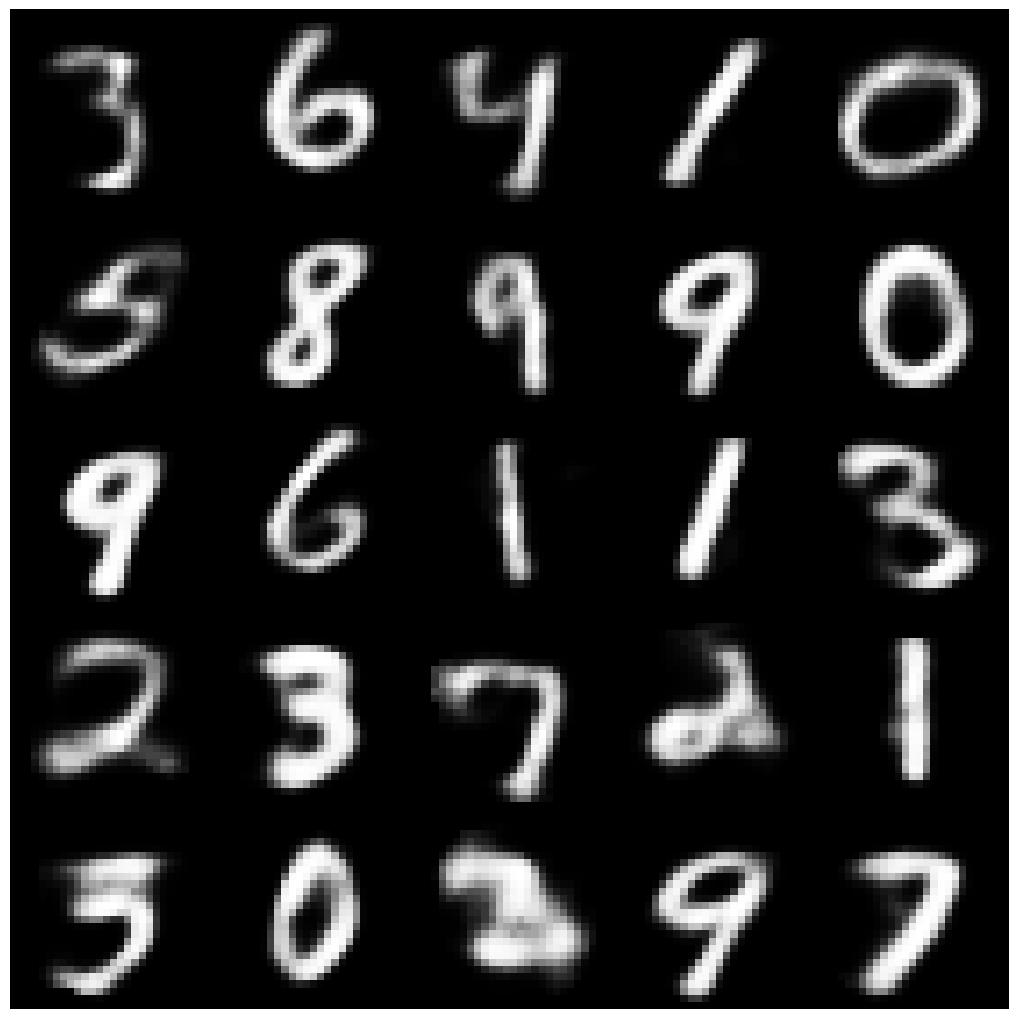

In [370]:
fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(10, 10))

for i in range(5):
    for j in range(5):
        axes[i][j].imshow(generated[i*5 + j].cpu().squeeze(0), cmap='gray')
        axes[i][j].axis('off')
plt.tight_layout(pad=0.)


## Visualizing reconstructions


In [371]:
reconstructions = trained_model.reconstruct(eval_dataset[:25].to(device)).detach().cpu()


reconstruction loss: 8.177327156066895 score proxy: -0.6959067583084106 dual proxy: -53.45298767089844 moment loss: 3.655435085296631 lambda reg: 9.828688621520996 reencode loss: 0.3713058829307556


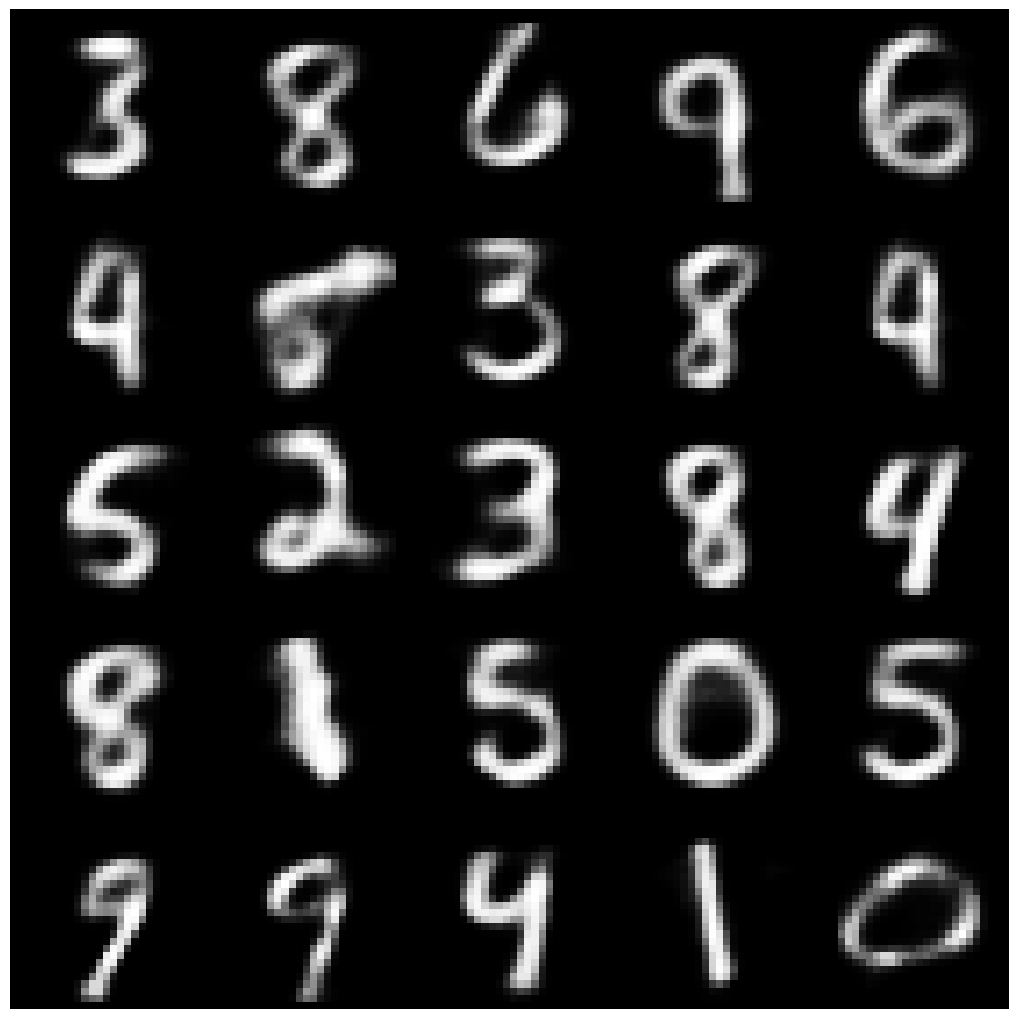

In [372]:
fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(10, 10))

for i in range(5):
    for j in range(5):
        axes[i][j].imshow(reconstructions[i*5 + j].cpu().squeeze(0), cmap='gray')
        axes[i][j].axis('off')
plt.tight_layout(pad=0.)


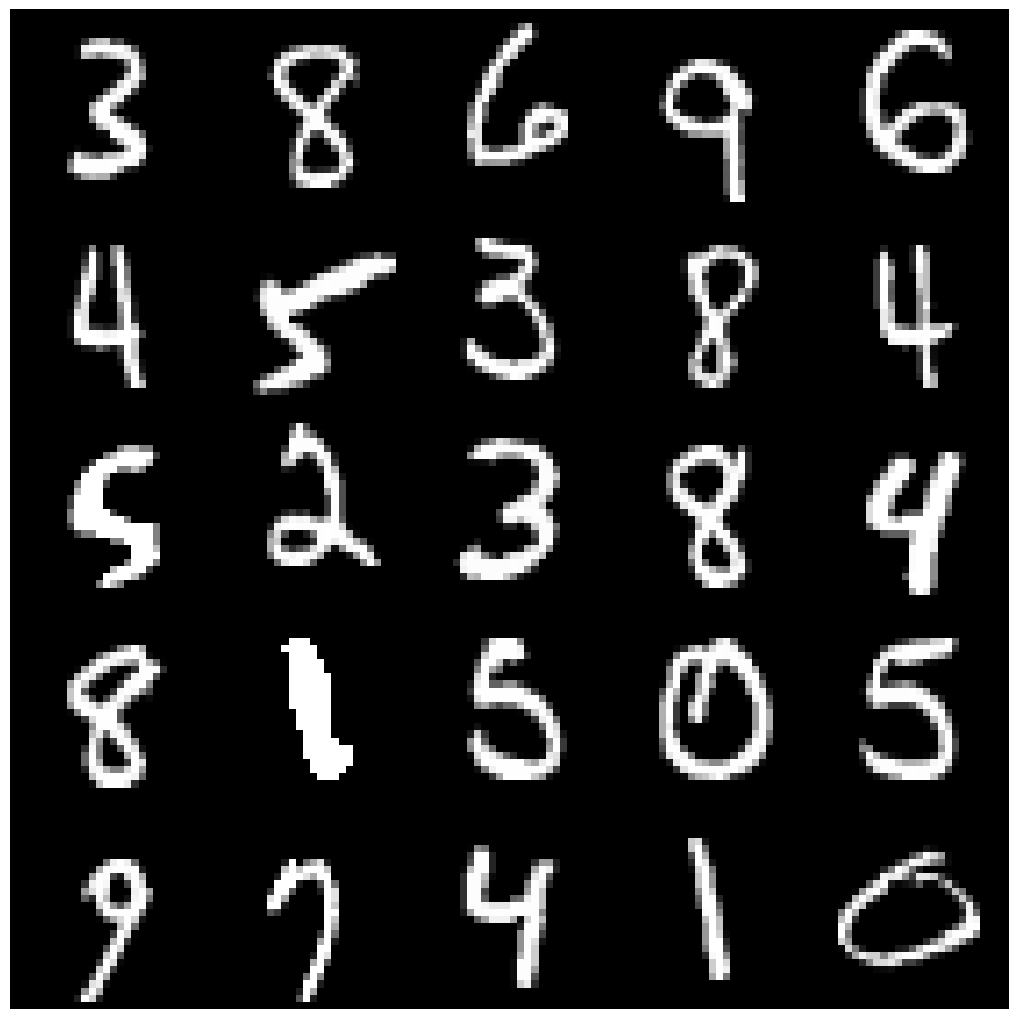

In [373]:
fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(10, 10))

for i in range(5):
    for j in range(5):
        axes[i][j].imshow(eval_dataset[i*5 + j].cpu().squeeze(0), cmap='gray')
        axes[i][j].axis('off')
plt.tight_layout(pad=0.)


## Visualizing interpolations


In [374]:
interpolations = trained_model.interpolate(
    eval_dataset[:5].to(device),
    eval_dataset[5:10].to(device),
    granularity=10
).detach().cpu()


reconstruction loss: 8.650662422180176 score proxy: -1.4266870021820068 dual proxy: -69.67414855957031 moment loss: 2.5022683143615723 lambda reg: 9.59113597869873 reencode loss: 0.34411856532096863
reconstruction loss: 10.017483711242676 score proxy: -0.361272394657135 dual proxy: -41.244140625 moment loss: 3.6310651302337646 lambda reg: 9.0547513961792 reencode loss: 0.47847211360931396


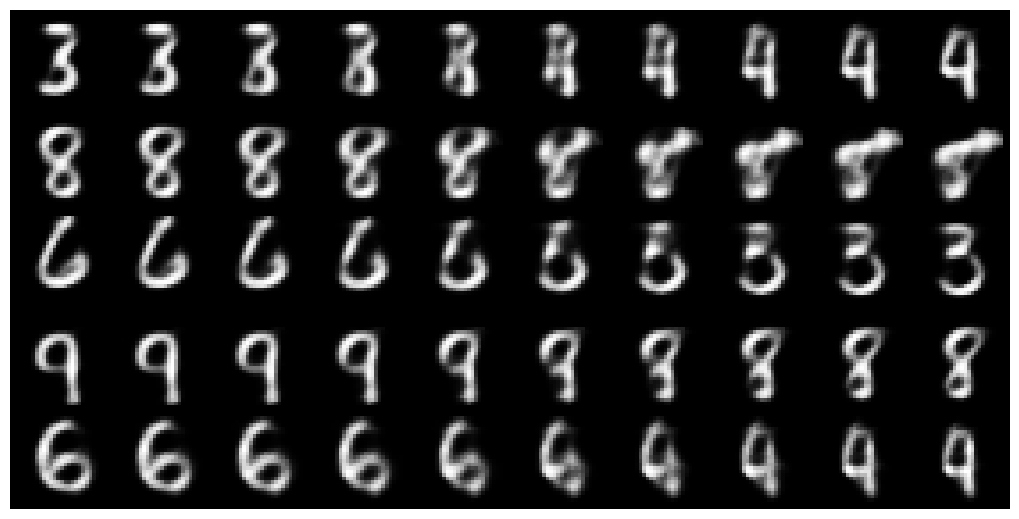

In [375]:
fig, axes = plt.subplots(nrows=5, ncols=10, figsize=(10, 5))

for i in range(5):
    for j in range(10):
        axes[i][j].imshow(interpolations[i, j].cpu().squeeze(0), cmap='gray')
        axes[i][j].axis('off')
plt.tight_layout(pad=0.)
